Train the network with the non-product formulation of the GCBF.

In [1]:
import torch
import torch.nn as nn
import tqdm
import pathlib

import numpy as np
import matplotlib.pyplot as plt

from diff_mfld_optim.geometry.connection import Connection
from diff_mfld_optim.geometry.metric import MetricField, RnMetricField
from diff_mfld_optim.optim.constrained import (
    ConstrainedSolverCfg,
    ConstrainedSolverMethod,
    ConstrainedSolverResult,
)
from diff_mfld_optim.optim.subsolver import SolverCfg, SubsolverMethod

from enum import Enum
from dataclasses import dataclass
from datetime import datetime
from torch.utils.data import DataLoader

import multiprocessing
from multiprocessing.pool import Pool

from controller import Controller
from diff_mfld_optim.optim.subsolver import OptimFunc, FuncArgs
from diff_mfld_optim.mfld_util import MfldCfg, dist_squared_map

import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer

from geo_diff_opt_layer_ml.util.nominal_mpc_dataloader import (
    EPISODES_TRAIN_DIR,
    EPISODES_VALID_DIR,
    MPC_TRAIN_DIR,
    MPC_VALID_DIR,
    KO_TRAIN_DIR,
    KO_VALID_DIR,
    MPCEpisode,
    MPCEpisodeDataset,
)

from gcbf import cbf_ko

from euclid_cbf import batched_cbf_ko_coeffs

from diff_mfld_optim.layers.diff_opt_layer import DiffMfldOptimLayer

In [2]:
# device = torch.device(
#     "cuda:0"
#     if torch.cuda.is_available()
#     else "mps" if torch.backends.mps.is_available() else "cpu"
# )
device = torch.device("cpu")
device

device(type='cpu')

In [3]:
mpc_train_dataset = MPCEpisodeDataset(EPISODES_TRAIN_DIR, MPC_TRAIN_DIR, KO_TRAIN_DIR, device=device)
mpc_valid_dataset = MPCEpisodeDataset(EPISODES_VALID_DIR, MPC_VALID_DIR, KO_VALID_DIR, device=device)

/home/samuel/Documents/School/UWaterloo_MASc/Research_Activities/research-geo-diff-opt-layer/geo_diff_opt_layer_ml/util/nominal_mpc_dataloader.py:131: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  torch.tensor(mpc_f["p_hist"], dtype=torch.float32, device=device),


In [4]:
# setup the geometric optimization problem


def gcbf_f(u: torch.Tensor, mfld_cfg: MfldCfg, u_nom: torch.Tensor, *_args):
    return 0.5 * dist_squared_map(u, u_nom, mfld_cfg)


def gcbf_g(
    u: torch.Tensor,
    _mfld_cfg: MfldCfg,
    # unused but the cost and constraint functions must accept the same number
    # of arguments as we're passing extra data during the forward pass which
    # iss used to compute the values and differentials of the cost and constraints
    _u_nom: torch.Tensor,
    p: torch.Tensor,
    ko: torch.Tensor,
    k1: torch.Tensor,
    k2: torch.Tensor,
):
    return cbf_ko(p, u, ko, k1, k2)


metric_field = RnMetricField(2)  # Euclidean for now
conn = metric_field.christoffels()  # Levi-Citivta connection
mfld_cfg = MfldCfg(metric_field, conn)

subsolver_cfg = SolverCfg()

print(subsolver_cfg)


constr_solv_cfg = ConstrainedSolverCfg(
    SubsolverMethod.RIEM_GRAD_DESCENT,
    subsolver_cfg,  # only one available (for now)
)

geo_constr_layer = DiffMfldOptimLayer(
    gcbf_f,
    [gcbf_g],
    [],
    mfld_cfg,
    constr_solv_cfg,
    ConstrainedSolverMethod.RALM,  # only one available (for now)
)

SolverCfg()


In [5]:
def _filter_batch(p, x_traj, y_traj, u, ko):
    # filters the batch so that we don't train on any cases where the current
    # state of the system is inside the keep-out region (as we generated them
    # randomly and cannot do this directly inside the dataloader)

    x, y = p[:, 0], p[:, 1]
    ko_x, ko_y, ko_rad = ko[:, 0], ko[:, 1], ko[:, 6]

    # determines which bached states are outside thet keep-out radius
    dist_sqr = (x - ko_x) ** 2 + (y - ko_y) ** 2
    rad_sqr = ko_rad**2

    outside_ko_idxs = dist_sqr >= rad_sqr

    # now filter teh batch based on the valid idxs
    return (
        p[outside_ko_idxs, :],
        x_traj[outside_ko_idxs],
        y_traj[outside_ko_idxs],
        u[outside_ko_idxs, :],
        ko[outside_ko_idxs, :],
    )


def _h_batch(p, x_traj, y_traj, u, ko):
    x, y = p[:, 0], p[:, 1]
    ko_x, ko_y, ko_rad = ko[:, 0], ko[:, 1], ko[:, 6]

    return torch.sqrt((ko_x - x) ** 2 + (ko_y - y) ** 2) - ko_rad


def _h_grad(p, x_traj, y_traj, u, ko):
    x, y = p[:, 0], p[:, 1]
    ko_x, ko_y, ko_rad = ko[:, 0], ko[:, 1], ko[:, 6]

    x_diff = -2 * (ko_x - x) / torch.sqrt((ko_x - x) ** 2 + (ko_y - y) ** 2)
    y_diff = -2 * (ko_y - y) / torch.sqrt((ko_x - x) ** 2 + (ko_y - y) ** 2)

    grad = torch.zeros((len(x), 2))
    grad[:, 0] = x_diff
    grad[:, 1] = y_diff

    return grad


def train_loop_gcbf(
    dataloader: DataLoader,
    model: Controller,
    loss_fn,
    optimizer: torch.optim.Optimizer,
    geo_constr_layer: CvxpyLayer,
    k1: torch.Tensor,
    k2: torch.Tensor,
    pool: Pool,
):
    model.train()

    batch_safe_loss = []
    batch_unsafe_loss = []
    for _batch, (p, x_traj, y_traj, u, ko) in enumerate(dataloader):
        # filters out all test cases where the current state is inside the
        # keep-out region (which would never occur in practice) as this
        # filtering operation cannot be done in the dataloader itself
        p_filt, x_traj_filt, y_traj_filt, u_filt, ko_filt = _filter_batch(
            p, x_traj, y_traj, u, ko
        )

        # CBF values
        h = _h_batch(p_filt, x_traj_filt, y_traj_filt, u_filt, ko_filt)
        h_grad = _h_grad(p_filt, x_traj_filt, y_traj_filt, u_filt, ko_filt)

        # makes a prediction on the control inputs which serves as the nominal
        # control input of the system
        pred_u = model(p_filt, x_traj_filt, y_traj_filt, h, h_grad)

        # uses the geometric safety layer to compute a safe input u
        safe_u = geo_constr_layer(
            pred_u,
            (pred_u, p_filt, ko_filt),  # batched arguments
            (k1, k2),  # non-batched arguments
            pool,  # for speed
        )
        print(safe_u)

        assert False

        # computes the loss between the filtered nominal controller and the
        # safe value of u (as computed through the CBF-QP)
        safe_loss = loss_fn(safe_u, u_filt)
        unsafe_loss = loss_fn(pred_u, u_filt)

        # backpropagation (through the optimization layer)
        safe_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        batch_safe_loss.append(safe_loss.item())
        batch_unsafe_loss.append(unsafe_loss.item())

    # this will be our metric of performance
    avg_safe_batch_loss = sum(batch_safe_loss) / len(batch_safe_loss)
    avg_unsafe_batch_loss = sum(batch_unsafe_loss) / len(batch_unsafe_loss)
    return avg_safe_batch_loss, avg_unsafe_batch_loss


def valid_loop_gcbf(
    dataloader: DataLoader,
    model: Controller,
    loss_fn,
    geo_constr_layer: CvxpyLayer,
    k1: torch.Tensor,
    k2: torch.Tensor,
    pool: Pool,
):
    model.eval()

    batch_safe_loss = []
    batch_unsafe_loss = []
    for _batch, (p, x_traj, y_traj, u, ko) in enumerate(dataloader):
        # filters out all test cases where the current state is inside the
        # keep-out region (which would never occur in practice) as this
        # filtering operation cannot be done in the dataloader itself
        p_filt, x_traj_filt, y_traj_filt, u_filt, ko_filt = _filter_batch(
            p, x_traj, y_traj, u, ko
        )

        # CBF values
        h = _h_batch(p_filt, x_traj_filt, y_traj_filt, u_filt, ko_filt)
        h_grad = _h_grad(p_filt, x_traj_filt, y_traj_filt, u_filt, ko_filt)

        # makes a prediction on the control inputs which serves as the nominal
        # control input of the system
        pred_u = model(p_filt, x_traj_filt, y_traj_filt, h, h_grad)

        # uses the geometric safety layer to compute a safe input u
        safe_u = geo_constr_layer(
            pred_u,
            (pred_u, p_filt, ko_filt),  # batched arguments
            (k1, k2),  # non-batched arguments
            pool,  # for speed
        )

        print(safe_u)
        assert False

        # computes the loss between the filtered nominal controller and the
        # safe value of u (as computed through the CBF-QP)+
        safe_loss = loss_fn(safe_u, u_filt)
        unsafe_loss = loss_fn(pred_u, u_filt)

        batch_safe_loss.append(safe_loss.item())
        batch_unsafe_loss.append(unsafe_loss.item())

    # this will be our metric of performance
    avg_safe_batch_loss = sum(batch_safe_loss) / len(batch_safe_loss)
    avg_unsafe_batch_loss = sum(batch_unsafe_loss) / len(batch_unsafe_loss)
    return avg_safe_batch_loss, avg_unsafe_batch_loss

In [6]:
# controller params
state_dim = 5  # num states of dynamic unicycle
control_dim = 2  # num of inputs
traj_dim = 2  # only feeding in the trajectory position (not vel., accel.)

num_hidden_1 = 60
num_hidden_2 = 60

cntrllr_model = Controller(
    state_dim=state_dim,
    control_dim=control_dim,
    traj_dim=traj_dim,
    num_hidden_1=num_hidden_1,
    num_hidden_2=num_hidden_2,
    has_cbfs=True,
).to(device)

In [7]:
# hyperparameters
epochs = 100
batch_size = 128
lr = 0.001

mpc_train_loader = DataLoader(mpc_train_dataset, batch_size=batch_size, shuffle=True)
mpc_valid_loader = DataLoader(mpc_valid_dataset, batch_size=batch_size, shuffle=True)

# cbf params
k1 = 0.1
k2 = 0.05

# optimization params

constr_solv_cfg.penalty = 0.3
constr_solv_cfg.penalty_growth = 1.4
constr_solv_cfg.max_iters = 1000
constr_solv_cfg.conv_eps = 1e-3

subsolver_cfg.conv_eps = 1e-3
subsolver_cfg.damp = 0.2
subsolver_cfg.damp_growth = 0.97
subsolver_cfg.max_iters = 1000


loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(params=cntrllr_model.parameters(), lr=lr)

# train the model

pbar = tqdm.tqdm(range(epochs), desc="Training")

# loss training history
safe_train_loss_hist = []
unsafe_train_loss_hist = []

safe_valid_loss_hist = []
unsafe_valid_loss_hist = []

# as we're passing batches to an optimization problem (that's unfortunately
# entirely written in Python) then for speed we need to create a
# multiprocessing context to use as many cores as possible

num_processes = 28
with multiprocessing.Pool(processes=num_processes) as pool:
    for epoch in pbar:
        safe_train_loss, unsafe_train_loss = train_loop_gcbf(
            mpc_train_loader,
            cntrllr_model,
            loss_fn,
            optimizer,
            geo_constr_layer,
            k1,
            k2,
            None,  # pool,
        )
        safe_valid_loss, unsafe_valid_loss = valid_loop_gcbf(
            mpc_valid_loader,
            cntrllr_model,
            loss_fn,
            geo_constr_layer,
            k1,
            k2,
            None,  # pool
        )
        pbar.set_postfix(
            safe_train_loss=safe_train_loss,
            unsafe_train_loss=unsafe_train_loss,
            safe_valid_loss=safe_valid_loss,
            unsafe_valid_loss=unsafe_valid_loss,
        )

        safe_train_loss_hist.append(safe_train_loss)
        unsafe_train_loss_hist.append(unsafe_train_loss)

        safe_valid_loss_hist.append(safe_valid_loss)
        unsafe_valid_loss_hist.append(unsafe_valid_loss)

Training:   0%|          | 0/100 [00:00<?, ?it/s]/home/samuel/Documents/School/UWaterloo_MASc/Research_Activities/research-geo-diff-opt-layer/diff_mfld_optim/geodesic/geodesic_funcs.py:49: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  raw_data = np.array(tensor.storage().tolist()[:total_len])
Training:   0%|          | 0/100 [00:39<?, ?it/s]

tensor([[-2.5598e-01,  5.4071e-02],
        [ 1.1320e-01,  1.6578e-02],
        [ 1.4285e-01,  1.4910e-02],
        [-7.1013e-01,  5.4018e-02],
        [-3.3383e-01,  5.3783e-02],
        [-1.3979e-01,  5.3071e-02],
        [ 7.3077e-02,  4.3086e-02],
        [ 4.1592e-01,  5.3476e-02],
        [ 6.5553e-01,  5.4098e-02],
        [-6.5660e-02,  5.2307e-02],
        [-1.0938e+01,  5.4076e-02],
        [-2.1715e-01,  5.4302e-02],
        [ 4.3494e-01,  5.1546e-02],
        [-3.8321e-01,  5.4173e-02],
        [ 1.7460e-01,  3.9237e-02],
        [ 2.1336e-01,  7.6671e-02],
        [ 1.1117e-01,  3.0379e-02],
        [ 1.2029e-01,  1.3613e-02],
        [ 9.3994e-02,  3.8201e-02],
        [ 1.6533e-01,  7.3452e-05],
        [ 1.1950e-01,  1.1219e-02],
        [ 1.5370e+00,  5.4074e-02],
        [-1.2532e+00,  5.4067e-02],
        [-3.2228e-01,  5.4077e-02],
        [ 3.1425e-02,  4.1091e-02],
        [ 1.4359e-01,  1.3246e-02],
        [-1.5750e-02,  5.3995e-02],
        [-2.3866e+00,  5.408

AssertionError: 

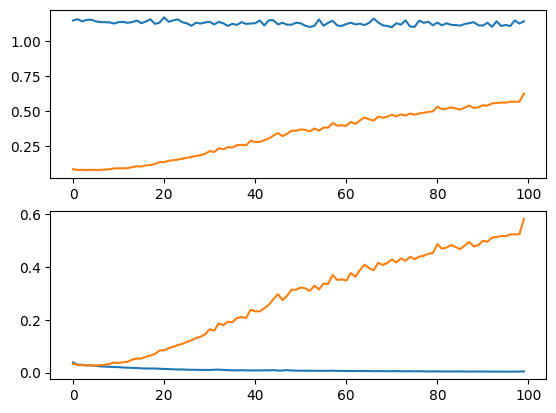

In [ ]:
safe_train_loss_hist = np.asarray(safe_train_loss_hist)
unsafe_train_loss_hist = np.asarray(unsafe_train_loss_hist)

safe_valid_loss_hist = np.asarray(safe_valid_loss_hist)
unsafe_valid_loss_hist = np.asarray(unsafe_valid_loss_hist)

fig, (ax1, ax2) = plt.subplots(2, 1)
# plt.plot(safe_train_loss_hist)

ax1.plot(safe_train_loss_hist)
ax1.plot(safe_valid_loss_hist)

ax2.plot(unsafe_train_loss_hist)
ax2.plot(unsafe_valid_loss_hist)


In [ ]:
# save the model with a unique timestamp (to prevent overwriting models)

output_dir = pathlib.Path("nn_with_gcbf_layer")
timestamp = datetime.now().strftime("%Y_%m_%d__%H_%M")

model_path = output_dir.joinpath(f"model_{timestamp}.pth")
torch.save(cntrllr_model.state_dict(), model_path)

np.save(output_dir.joinpath(f"safe_train_loss_hist_{timestamp}"), safe_train_loss_hist)
np.save(
    output_dir.joinpath(f"unsafe_train_loss_hist_{timestamp}"), unsafe_train_loss_hist
)
np.save(output_dir.joinpath(f"safe_valid_loss_hist_{timestamp}"), safe_valid_loss_hist)
np.save(
    output_dir.joinpath(f"unsafe_valid_loss_hist_{timestamp}"), unsafe_valid_loss_hist
)